### Gaussian formulae ###

In [3]:
from RKkit.rkkit import *
from sage.rings.qqbar import *
from sage.functions.orthogonal_polys import legendre_P

We must compute in exact numbers, generally algebraic numbers (AA if real, QQbar else).

In [4]:
R = PolynomialRing(AA,"x")
x=R.gen()

Build Gaussian RK methods, find stability properties, compute order using rooted trees, draw stability function and order star.

*Z!* Computing order with rooted trees is very expensive when n grows!


Nom : Gauss-2
A-stable:  True
L-stable:  False
order:  4
stability functions:  (z^2 + 6*z + 12)/(z^2 - 6*z + 12)
stiffly accurate?  False
algebraically stable? True
conserve quadratic invariants? True


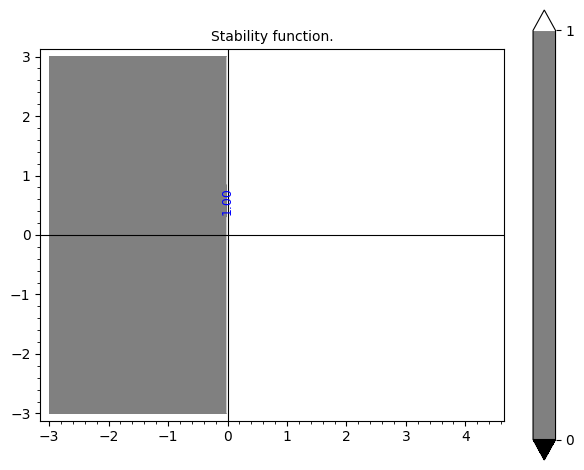

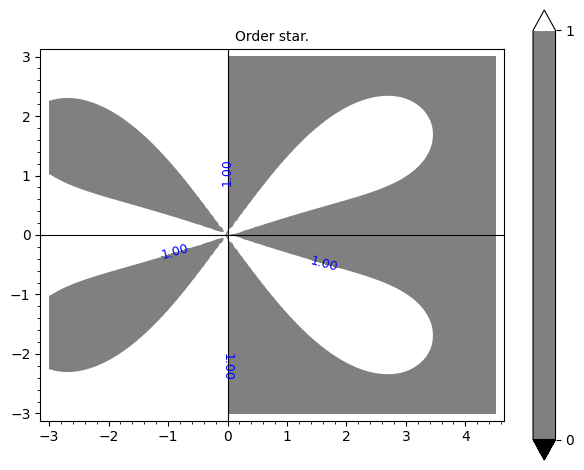


Nom : Gauss-3
A-stable:  True
L-stable:  False
order:  6
stability functions:  (-z^3 - 12*z^2 - 60*z - 120)/(z^3 - 12*z^2 + 60*z - 120)
stiffly accurate?  False
algebraically stable? True
conserve quadratic invariants? True


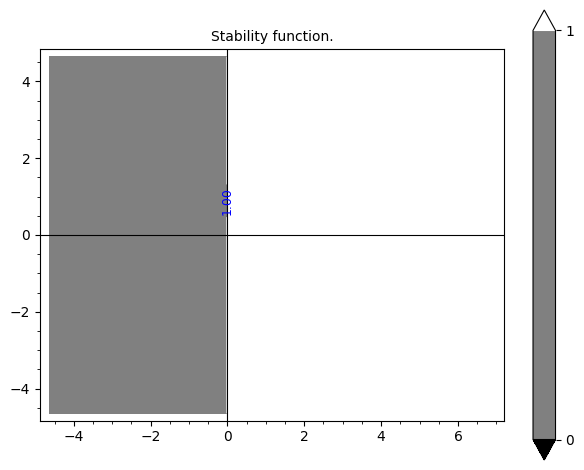

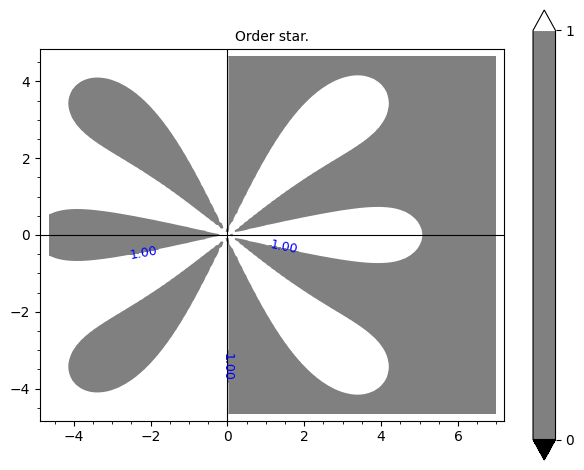

In [5]:
for n in range(2,4):
    c = [(s[0]+1)/2 for s in R(legendre_P(n,x)).roots()] #roots of shifted polynomials (collocation points)
    GenRK = RKcolloc.colloc(c,R,"Gauss-"+str(n))# coefficients of the RK formula

    #_RKcolloc.colloc as returned a class (a type). We must instantiate it:_

    G=GenRK()

    F=RKformula(G)
    #start some tests
    print("\nNom :",G.Title)
    print("A-stable: ",F.is_A_stable())
    print("L-stable: ",F.is_L_stable())
    print("order: ",F.order())
    print("stability functions: ",F.stability_function())
    print("stiffly accurate? ",F.is_stiffly_accurate())
    print("algebraically stable?",F.is_algebraically_stable())
    print("conserve quadratic invariants?",F.conserve_quadratic_invariants())
    p=RKplot(F,fill=True,ncurves=2,Enlarge=1)
    p.show()
    q=RKplot(F,fill=True,ncurves=2,type="star",Enlarge=1)
    q.show()